In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
IMG_SIZE = 512

def load_data(img_paths, mask_paths):
    X, Y = [], []
    for ip, mp in zip(img_paths, mask_paths):
        img = cv2.imread(ip)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0

        mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)     # ensure binary
        mask = 1 - mask                        # ulcer=1

        X.append(img)
        Y.append(mask[...,None])
    return np.array(X), np.array(Y)


In [ ]:
import cv2, numpy as np

def cornea_mask_hough(rgb_img, rmin=60, rmax=200):
    # rgb_img in [0,1], shape (H,W,3)
    img = (rgb_img*255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (7,7), 0)

    circles = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT,
        dp=1.2, minDist=gray.shape[0]//2,
        param1=120, param2=30,
        minRadius=rmin, maxRadius=rmax
    )
    mask = np.zeros(gray.shape[:2], dtype=np.uint8)
    if circles is None:
        return mask  # all zeros if not found
    x,y,r = np.round(circles[0][0]).astype(int)
    cv2.circle(mask, (x,y), r, 1, -1)
    return mask


In [ ]:
import os, numpy as np, cv2, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from scipy.stats import wilcoxon

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

BASE="/content/drive/MyDrive/corneal_ulcer_dataset"


Mounted at /content/drive


In [ ]:
X_train = np.load(os.path.join(BASE, "train_images.npy")).astype(np.float32)
Y_train = np.load(os.path.join(BASE, "train_ulcer.npy")).astype(np.uint8)

X_val   = np.load(os.path.join(BASE, "val_images.npy")).astype(np.float32)
Y_val   = np.load(os.path.join(BASE, "val_ulcer.npy")).astype(np.uint8)

X_test  = np.load(os.path.join(BASE, "test_images.npy")).astype(np.float32)
Y_test  = np.load(os.path.join(BASE, "test_ulcer.npy")).astype(np.uint8)

# ensure channel dim for masks
if Y_train.ndim == 3: Y_train = Y_train[..., None]
if Y_val.ndim == 3:   Y_val   = Y_val[..., None]
if Y_test.ndim == 3:  Y_test  = Y_test[..., None]

print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)


(247, 256, 256, 3) (247, 256, 256, 1) (72, 256, 256, 3) (72, 256, 256, 1)


In [ ]:
Y_train_ulcer = 1 - Y_train
Y_val_ulcer   = 1 - Y_val
Y_test_ulcer  = 1 - Y_test

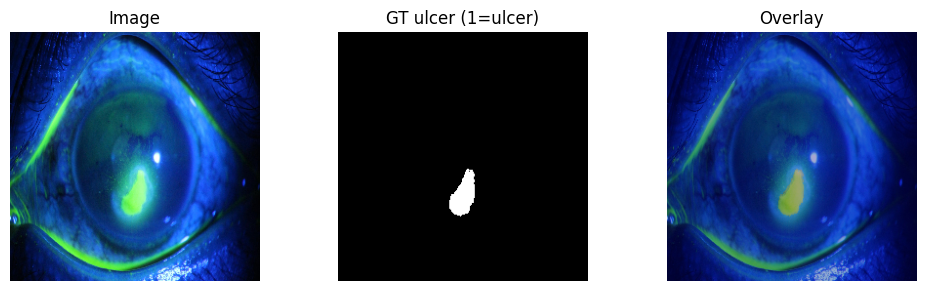

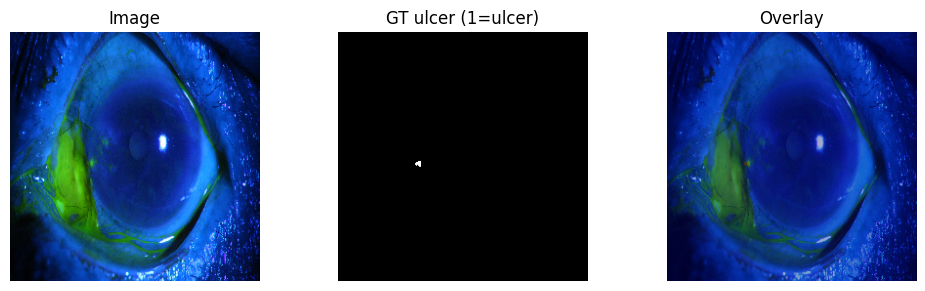

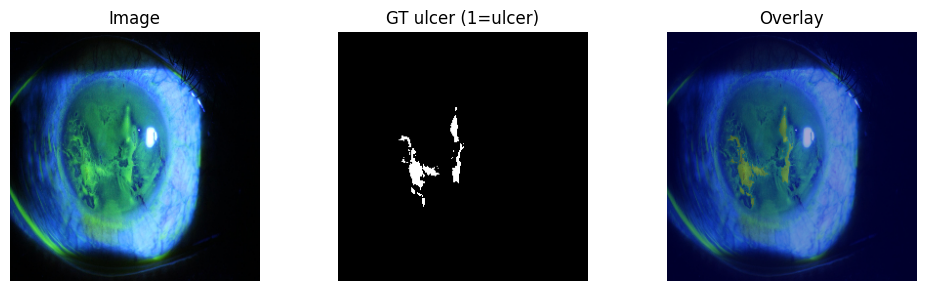

In [ ]:
def show_sample(i=0):
    img = X_train[i]
    gt  = Y_train_ulcer[i,...,0]
    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("GT ulcer (1=ulcer)"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img); plt.imshow(gt, alpha=0.35, cmap="jet"); plt.title("Overlay"); plt.axis("off")
    plt.tight_layout(); plt.show()

show_sample(0)
show_sample(10)
show_sample(25)


In [ ]:
def cornea_mask_hough(rgb_img_01, rmin=60, rmax=260):
    # rgb_img_01 is float [0,1], (H,W,3)
    img = (rgb_img_01 * 255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (7,7), 0)

    circles = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT,
        dp=1.2, minDist=gray.shape[0]//2,
        param1=120, param2=30,
        minRadius=rmin, maxRadius=rmax
    )
    mask = np.zeros(gray.shape[:2], dtype=np.uint8)
    if circles is None:
        return mask
    x,y,r = np.round(circles[0][0]).astype(int)
    cv2.circle(mask, (x,y), r, 1, -1)
    return mask


In [ ]:
def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape):
    inp = layers.Input(shape=input_shape)

    c1 = conv_block(inp, 32); p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1, 64);  p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2, 128); p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3, 256); p4 = layers.MaxPool2D()(c4)

    bn = conv_block(p4, 512)

    u1 = layers.UpSampling2D()(bn); u1 = layers.Concatenate()([u1, c4]); c5 = conv_block(u1, 256)
    u2 = layers.UpSampling2D()(c5); u2 = layers.Concatenate()([u2, c3]); c6 = conv_block(u2, 128)
    u3 = layers.UpSampling2D()(c6); u3 = layers.Concatenate()([u3, c2]); c7 = conv_block(u3, 64)
    u4 = layers.UpSampling2D()(c7); u4 = layers.Concatenate()([u4, c1]); c8 = conv_block(u4, 32)

    out = layers.Conv2D(1, 1, activation="sigmoid")(c8)  # predicts P(ulcer)
    return Model(inp, out)

model_real = build_unet(X_train.shape[1:])
model_real.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75, eps=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1-y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1-y_pred))
    tversky = (tp + eps) / (tp + alpha*fp + beta*fn + eps)
    return tf.pow((1 - tversky), gamma)


In [ ]:
model_real.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss=focal_tversky_loss)


In [ ]:
ckpt_path = "/content/drive/MyDrive/corneal_ulcer_dataset/best_real_only.keras"

cb = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path,
        save_best_only=True,
        monitor="val_loss"
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor="val_loss"
    )
]

hist = model_real.fit(
    X_train, Y_train_ulcer,
    validation_data=(X_val, Y_val_ulcer),
    epochs=60,
    batch_size=8,
    callbacks=cb,
    verbose=1
)


Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - loss: 0.9389 - val_loss: 0.9593
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - loss: 0.8853 - val_loss: 0.9588
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - loss: 0.8462 - val_loss: 0.9596
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - loss: 0.8289 - val_loss: 0.9597
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - loss: 0.8146 - val_loss: 0.9601
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.8070 - val_loss: 0.9607
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - loss: 0.7968 - val_loss: 0.9620
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.7873 - val_loss: 0.9634
Epoch 9/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 0.7811 - val_loss: 0.9627
Epoch 10/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.7696 - val_loss: 0.9641
Epoch 11/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - loss: 0.7596 - val_loss: 0.9581
Epoch 12/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step -

In [ ]:
def dice_np(a,b,eps=1e-6):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

def iou_np(a,b,eps=1e-6):
    a=a.reshape(-1).astype(np.uint8)
    b=b.reshape(-1).astype(np.uint8)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return (inter+eps)/(union+eps)

def eval_model(model, X, Y_ulcer, threshold=0.5, use_roi=False):
    probs = model.predict(X, verbose=0)[...,0]   # P(ulcer)
    pred_bin = (probs > threshold).astype(np.uint8)
    gt = Y_ulcer[...,0].astype(np.uint8)

    if use_roi:
        # Apply per-image ROI to both GT and pred
        pred2, gt2 = [], []
        for i in range(len(X)):
            roi = cornea_mask_hough(X[i])
            pred2.append(pred_bin[i] * roi)
            gt2.append(gt[i] * roi)
        pred_bin = np.array(pred2)
        gt = np.array(gt2)

    dices = np.array([dice_np(gt[i], pred_bin[i]) for i in range(len(gt))])
    ious  = np.array([iou_np(gt[i], pred_bin[i])  for i in range(len(gt))])
    return dices, ious, probs, pred_bin

d_real, i_real, probs_real, pred_real = eval_model(model_real, X_test, Y_test_ulcer, threshold=0.5, use_roi=False)

print("REAL-only (no ROI): Dice mean/median", d_real.mean(), np.median(d_real), " IoU mean/median", i_real.mean(), np.median(i_real))
print("min Dice:", d_real.min(), "std:", d_real.std())
d_real_roi, i_real_roi, _, _ = eval_model(model_real, X_test, Y_test_ulcer, threshold=0.5, use_roi=True)
print("REAL-only (ROI): Dice mean/median", d_real_roi.mean(), np.median(d_real_roi), " IoU mean/median", i_real_roi.mean(), np.median(i_real_roi))


REAL-only (no ROI): Dice mean/median 0.6860920198594141 0.7949775243951602  IoU mean/median 0.589957451490198 0.6597255934576609
min Dice: 9.000900081907379e-10 std: 0.30308748213537223
REAL-only (ROI): Dice mean/median 0.7296380990681383 0.8283113632047234  IoU mean/median 0.6505384047962101 0.7070098126470759


In [ ]:
syn_npz_path = os.path.join(BASE, "synthetic_v4_noise_arrays.npz")
data = np.load(syn_npz_path)

X_syn = data["X_syn"].astype(np.float32)
Y_syn = data["Y_syn"].astype(np.uint8)

if Y_syn.ndim == 3:
    Y_syn = Y_syn[..., None]

Y_syn_ulcer = Y_syn


X_train_m = np.concatenate([X_train, X_syn], axis=0)
Y_train_m = np.concatenate([Y_train_ulcer, Y_syn_ulcer], axis=0)


perm = np.random.permutation(len(X_train_m))
X_train_m = X_train_m[perm]
Y_train_m = Y_train_m[perm]

print("Merged X:", X_train_m.shape, X_train_m.dtype)
print("Merged Y:", Y_train_m.shape, Y_train_m.dtype, "unique:", np.unique(Y_train_m))


Merged X: (3952, 256, 256, 3) float32
Merged Y: (3952, 256, 256, 1) uint8 unique: [0 1]


In [ ]:
model_mixed = build_unet(X_train.shape[1:])
model_mixed.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                    loss=focal_tversky_loss)  # same loss

cb2 = [
    tf.keras.callbacks.ModelCheckpoint("best_mixed.keras", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")
]

model_mixed.fit(
    X_train_m, Y_train_m,
    validation_data=(X_val, Y_val_ulcer),
    epochs=60,
    batch_size=8,
    callbacks=cb2,
    verbose=1
)


NameError: name 'build_unet' is not defined

In [ ]:
import tensorflow as tf
import numpy as np
import os, glob

AUTOTUNE = tf.data.AUTOTUNE
batch_size = 1  # keep small

X_train = X_train.astype(np.float32)
Y_train_ulcer = Y_train_ulcer.astype(np.uint8)
if Y_train_ulcer.ndim == 3:
    Y_train_ulcer = Y_train_ulcer[..., None]

X_val = X_val.astype(np.float32)
Y_val_ulcer = Y_val_ulcer.astype(np.uint8)
if Y_val_ulcer.ndim == 3:
    Y_val_ulcer = Y_val_ulcer[..., None]

ds_real = tf.data.Dataset.from_tensor_slices((X_train, Y_train_ulcer)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .batch(batch_size) \
    .prefetch(AUTOTUNE)


In [ ]:
syn_img_dir = os.path.join(BASE, "synthetic_v4_noise/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v4_noise/ulcer_masks")

syn_img_paths = sorted(glob.glob(os.path.join(syn_img_dir, "*.png")))
syn_msk_paths = [os.path.join(syn_msk_dir, os.path.basename(p)) for p in syn_img_paths]

print("Synthetic count:", len(syn_img_paths))

def load_syn(img_path, msk_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # float32 [0,1]

    msk = tf.io.read_file(msk_path)
    msk = tf.image.decode_png(msk, channels=1)
    msk = tf.cast(msk > 0, tf.uint8)  # ulcer=1
    return img, msk

ds_syn = tf.data.Dataset.from_tensor_slices((syn_img_paths, syn_msk_paths)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .map(load_syn, num_parallel_calls=AUTOTUNE) \
    .batch(batch_size) \
    .prefetch(AUTOTUNE)


Synthetic count: 3705


In [ ]:
ds_train = tf.data.Dataset.sample_from_datasets(
    [ds_real, ds_syn],
    weights=[0.8, 0.2]   # start small synthetic share
)

steps_per_epoch = int(np.ceil(len(X_train) / batch_size))


In [ ]:
tf.keras.backend.clear_session()

ckpt_path = "/content/drive/MyDrive/corneal_ulcer_dataset/best_mixed.keras"

model_mixed = build_unet(X_train.shape[1:])
model_mixed.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_tversky_loss
)

cb2 = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.TerminateOnNaN()
]

history = model_mixed.fit(
    ds_train,
    validation_data=(X_val, Y_val_ulcer),
    epochs=60,
    steps_per_epoch=steps_per_epoch,
    callbacks=cb2,
    verbose=1
)


Epoch 1/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 128s 373ms/step - loss: 0.8411 - val_loss: 0.9254
Epoch 2/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 38s 155ms/step - loss: 0.5586 - val_loss: 0.9785
Epoch 3/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 48s 194ms/step - loss: 0.1047 - val_loss: 0.9866
Epoch 4/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 44s 179ms/step - loss: 0.0787 - val_loss: 0.9968
Epoch 5/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 47s 192ms/step - loss: 0.0613 - val_loss: 0.9874
Epoch 6/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 49s 199ms/step - loss: 0.0506 - val_loss: 0.9941
Epoch 7/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 43s 176ms/step - loss: 0.0402 - val_loss: 0.9618
Epoch 8/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 42s 171ms/step - loss: 0.0318 - val_loss: 0.9613
Epoch 9/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 49s 198ms/step - loss: 0.0276 - val_loss: 0.9853
Epoch 10/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 45s 183ms/step - loss: 0.0229 - val_loss: 0.9791
Epoch 11/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 44s 179ms/step - loss: 0.0193 - val_loss: 0.9627


In [ ]:
import tensorflow as tf
import numpy as np
import os, glob

AUTOTUNE = tf.data.AUTOTUNE
batch_size = 2  # use 1 if you still crash
lr = 1e-4

# ---- real ds from arrays ----
X_train = X_train.astype(np.float32)
Y_train_ulcer = Y_train_ulcer.astype(np.uint8)
if Y_train_ulcer.ndim == 3: Y_train_ulcer = Y_train_ulcer[..., None]

X_val = X_val.astype(np.float32)
Y_val_ulcer = Y_val_ulcer.astype(np.uint8)
if Y_val_ulcer.ndim == 3: Y_val_ulcer = Y_val_ulcer[..., None]

ds_real = tf.data.Dataset.from_tensor_slices((X_train, Y_train_ulcer)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .batch(batch_size) \
    .prefetch(AUTOTUNE)

# ---- synthetic ds from PNG folders (streaming) ----
syn_img_dir = os.path.join(BASE, "synthetic_v4_noise/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v4_noise/ulcer_masks")

syn_img_paths = sorted(glob.glob(os.path.join(syn_img_dir, "*.png")))
syn_msk_paths = [os.path.join(syn_msk_dir, os.path.basename(p)) for p in syn_img_paths]

def load_syn(img_path, msk_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    msk = tf.io.read_file(msk_path)
    msk = tf.image.decode_png(msk, channels=1)
    msk = tf.cast(msk > 0, tf.uint8)
    return img, msk

ds_syn = tf.data.Dataset.from_tensor_slices((syn_img_paths, syn_msk_paths)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .map(load_syn, num_parallel_calls=AUTOTUNE) \
    .batch(batch_size) \
    .prefetch(AUTOTUNE)

# ---- mix: keep synthetic SMALL so it doesn't hurt val ----
ds_train = tf.data.Dataset.sample_from_datasets([ds_real, ds_syn], weights=[0.95, 0.05])

# epoch length = "one pass worth of real"
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))

# ---- build/compile ----
tf.keras.backend.clear_session()
model_mixed = build_unet(X_train.shape[1:])
model_mixed.compile(optimizer=tf.keras.optimizers.Adam(lr), loss=focal_tversky_loss)

ckpt_mixed = "/content/drive/MyDrive/corneal_ulcer_dataset/best_mixed.keras"

cb_mixed = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_mixed, save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
]

hist_mixed = model_mixed.fit(
    ds_train,
    validation_data=(X_val, Y_val_ulcer),
    epochs=60,
    steps_per_epoch=steps_per_epoch,
    callbacks=cb_mixed,
    verbose=1
)


Epoch 1/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - loss: 0.8879 - val_loss: 0.9549
Epoch 2/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 420ms/step - loss: 0.3861 - val_loss: 0.9655
Epoch 3/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.1111 - val_loss: 0.9623
Epoch 4/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.0871 - val_loss: 0.9769
Epoch 5/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.0766 - val_loss: 0.9719
Epoch 6/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.0647 - val_loss: 0.9653
Epoch 7/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 0.0591 - val_loss: 0.9915
Epoch 8/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.0566 - val_loss: 0.9802
Epoch 9/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.0477 - val_loss: 0.9640
Epoch 10/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0429 - val_loss: 0.9759
Epoch 11/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0385 - val_loss: 0.9836


In [ ]:
real_path  = "/content/drive/MyDrive/corneal_ulcer_dataset/best_real_only.keras"
mixed_path = "/content/drive/MyDrive/corneal_ulcer_dataset/best_mixed.keras"

model_real_best  = tf.keras.models.load_model(real_path,  custom_objects={"focal_tversky_loss": focal_tversky_loss})
model_mixed_best = tf.keras.models.load_model(mixed_path, custom_objects={"focal_tversky_loss": focal_tversky_loss})


In [ ]:
import numpy as np

def dice_np(a,b,eps=1e-6):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

def iou_np(a,b,eps=1e-6):
    a=a.reshape(-1).astype(np.uint8)
    b=b.reshape(-1).astype(np.uint8)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return (inter+eps)/(union+eps)

def eval_model(model, X, Y_ulcer, threshold=0.5, use_roi=False):
    probs = model.predict(X, verbose=0)[...,0]
    pred_bin = (probs > threshold).astype(np.uint8)
    gt = Y_ulcer[...,0].astype(np.uint8)

    if use_roi:
        pred2, gt2 = [], []
        for i in range(len(X)):
            roi = cornea_mask_hough(X[i])  # <-- your ROI function
            pred2.append(pred_bin[i] * roi)
            gt2.append(gt[i] * roi)
        pred_bin = np.array(pred2)
        gt = np.array(gt2)

    dices = np.array([dice_np(gt[i], pred_bin[i]) for i in range(len(gt))])
    ious  = np.array([iou_np(gt[i], pred_bin[i])  for i in range(len(gt))])
    return dices, ious, probs, pred_bin


In [ ]:
X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
    Y_test_eval = Y_test_eval[...,None]

# --- REAL ---
d_r, i_r, probs_r, pred_r = eval_model(model_real_best,  X_test_eval, Y_test_eval, threshold=0.5, use_roi=False)
d_r_roi, i_r_roi, _, _    = eval_model(model_real_best,  X_test_eval, Y_test_eval, threshold=0.5, use_roi=True)

# --- MIXED ---
d_m, i_m, probs_m, pred_m = eval_model(model_mixed_best, X_test_eval, Y_test_eval, threshold=0.5, use_roi=False)
d_m_roi, i_m_roi, _, _    = eval_model(model_mixed_best, X_test_eval, Y_test_eval, threshold=0.5, use_roi=True)

print("=== TEST (no ROI) ===")
print("REAL  Dice mean/median:", d_r.mean(), np.median(d_r), " IoU mean/median:", i_r.mean(), np.median(i_r))
print("MIXED Dice mean/median:", d_m.mean(), np.median(d_m), " IoU mean/median:", i_m.mean(), np.median(i_m))

print("\n=== TEST (ROI) ===")
print("REAL  Dice mean/median:", d_r_roi.mean(), np.median(d_r_roi), " IoU mean/median:", i_r_roi.mean(), np.median(i_r_roi))
print("MIXED Dice mean/median:", d_m_roi.mean(), np.median(d_m_roi), " IoU mean/median:", i_m_roi.mean(), np.median(i_m_roi))


=== TEST (no ROI) ===
REAL  Dice mean/median: 0.6860920198594141 0.7949775243951602  IoU mean/median: 0.589957451490198 0.6597255934576609
MIXED Dice mean/median: 1.9230176561844435e-09 5.946835569287473e-10  IoU mean/median: 1.9230176561844435e-09 5.946835569287473e-10

=== TEST (ROI) ===
REAL  Dice mean/median: 0.7296380990681383 0.8283113632047234  IoU mean/median: 0.6505384047962101 0.7070098126470759
MIXED Dice mean/median: 0.18055555740126522 1.2968077012197534e-09  IoU mean/median: 0.18055555740126522 1.2968077012197534e-09


ROI: slit lamp image -> cornea localisation ->segmentation

Pretrain on synthetic, then fine-tune on real-only This usually works much better than naive mixing. Stage 1: train on synthetic only for a few epochs Stage 2: fine-tune on real only (this is what matters for performance)

In [ ]:
import tensorflow as tf
import numpy as np
import os, glob

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (256, 256)


X_train = X_train.astype(np.float32)
Y_train_ulcer = Y_train_ulcer.astype(np.uint8)
if Y_train_ulcer.ndim == 3: Y_train_ulcer = Y_train_ulcer[..., None]

X_val = X_val.astype(np.float32)
Y_val_ulcer = Y_val_ulcer.astype(np.uint8)
if Y_val_ulcer.ndim == 3: Y_val_ulcer = Y_val_ulcer[..., None]

batch_size_real = 2
ds_real = tf.data.Dataset.from_tensor_slices((X_train, Y_train_ulcer)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .batch(batch_size_real) \
    .prefetch(AUTOTUNE)

steps_real = int(np.ceil(len(X_train) / batch_size_real))

syn_img_dir = os.path.join(BASE, "synthetic_v4_noise/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v4_noise/ulcer_masks")

syn_img_paths = sorted(glob.glob(os.path.join(syn_img_dir, "*.png")))
syn_msk_paths = [os.path.join(syn_msk_dir, os.path.basename(p)) for p in syn_img_paths]

print("Synthetic count:", len(syn_img_paths))

def load_syn(img_path, msk_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]

    msk = tf.io.read_file(msk_path)
    msk = tf.image.decode_png(msk, channels=1)
    msk = tf.cast(msk > 0, tf.uint8)  # ulcer=1
    return img, msk

batch_size_syn = 2
ds_syn = tf.data.Dataset.from_tensor_slices((syn_img_paths, syn_msk_paths)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .map(load_syn, num_parallel_calls=AUTOTUNE) \
    .batch(batch_size_syn) \
    .prefetch(AUTOTUNE)

steps_syn = max(1, int(np.ceil(len(syn_img_paths) / batch_size_syn)))


Synthetic count: 3705


In [ ]:
tf.keras.backend.clear_session()

model = build_unet(X_train.shape[1:])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=focal_tversky_loss)

pre_ckpt = "/content/drive/MyDrive/corneal_ulcer_dataset/pretrain_syn.keras"

cb_pre = [
    tf.keras.callbacks.ModelCheckpoint(pre_ckpt, save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
]

hist_pre = model.fit(
    ds_syn,
    validation_data=(X_val, Y_val_ulcer),   # validate on REAL so we don’t overfit synthetic
    epochs=10,                               # small number
    steps_per_epoch=steps_syn,
    callbacks=cb_pre,
    verbose=1
)


Epoch 1/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 292s 143ms/step - loss: 0.0835 - val_loss: 0.9645
Epoch 2/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 57ms/step - loss: 0.0135 - val_loss: 0.9686
Epoch 3/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 57ms/step - loss: 0.0048 - val_loss: 0.9740
Epoch 4/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 57ms/step - loss: 0.0019 - val_loss: 0.9738
Epoch 5/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 106s 57ms/step - loss: 0.0013 - val_loss: 0.9611
Epoch 6/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 107s 58ms/step - loss: 7.8811e-04 - val_loss: 0.9736
Epoch 7/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 57ms/step - loss: 5.0382e-04 - val_loss: 0.9745
Epoch 8/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 57ms/step - loss: 7.6118e-04 - val_loss: 0.9709
Epoch 9/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 57ms/step - loss: 3.7122e-04 - val_loss: 0.9695
Epoch 10/10
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 105s 56ms/step - loss: 3.1205e-04 - val_loss: 0.9662


In [ ]:
ft_ckpt = "/content/drive/MyDrive/corneal_ulcer_dataset/best_ft_real_from_syn.keras"

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=focal_tversky_loss)

cb_ft = [
    tf.keras.callbacks.ModelCheckpoint(ft_ckpt, save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
]

hist_ft = model.fit(
    ds_real,
    validation_data=(X_val, Y_val_ulcer),
    epochs=60,
    steps_per_epoch=steps_real,
    callbacks=cb_ft,
    verbose=1
)


Epoch 1/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - loss: 0.9778 - val_loss: 0.9594
Epoch 2/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.9721 - val_loss: 0.9554
Epoch 3/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.9633 - val_loss: 0.9553
Epoch 4/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 0.9481 - val_loss: 0.9514
Epoch 5/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.9312 - val_loss: 0.9202
Epoch 6/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 0.9176 - val_loss: 0.9117
Epoch 7/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.9206 - val_loss: 0.9053
Epoch 8/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.9231 - val_loss: 0.9036
Epoch 9/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 0.9128 - val_loss: 0.8979
Epoch 10/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.9182 - val_loss: 0.8904
Epoch 11/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 0.9137 - val_loss: 0.8865
Epoch 12/60
124/124 ━━━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
import numpy as np

BASELINE_PATH = "/content/drive/MyDrive/corneal_ulcer_dataset/best_real_only.keras"
FT_PATH       = "/content/drive/MyDrive/corneal_ulcer_dataset/best_ft_real_from_syn.keras"

# Load models
baseline_model = tf.keras.models.load_model(
    BASELINE_PATH, custom_objects={"focal_tversky_loss": focal_tversky_loss}
)
ft_model = tf.keras.models.load_model(
    FT_PATH, custom_objects={"focal_tversky_loss": focal_tversky_loss}
)

def dice_np(a,b,eps=1e-6):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

def iou_np(a,b,eps=1e-6):
    a=a.reshape(-1).astype(np.uint8)
    b=b.reshape(-1).astype(np.uint8)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return (inter+eps)/(union+eps)

def eval_model(model, X, Y_ulcer, threshold=0.5, use_roi=False):
    probs = model.predict(X, verbose=0)[...,0]
    pred_bin = (probs > threshold).astype(np.uint8)
    gt = Y_ulcer[...,0].astype(np.uint8)

    if use_roi:
        pred2, gt2 = [], []
        for i in range(len(X)):
            roi = cornea_mask_hough(X[i])
            pred2.append(pred_bin[i] * roi)
            gt2.append(gt[i] * roi)
        pred_bin = np.array(pred2)
        gt = np.array(gt2)

    dices = np.array([dice_np(gt[i], pred_bin[i]) for i in range(len(gt))])
    ious  = np.array([iou_np(gt[i], pred_bin[i])  for i in range(len(gt))])
    return dices, ious


X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
    Y_test_eval = Y_test_eval[..., None]

d_base, i_base = eval_model(baseline_model, X_test_eval, Y_test_eval, threshold=0.5, use_roi=False)
d_ft,   i_ft   = eval_model(ft_model,       X_test_eval, Y_test_eval, threshold=0.5, use_roi=False)

print("=== TEST (no ROI) ===")
print("BASELINE Dice mean/median:", d_base.mean(), np.median(d_base), " IoU mean/median:", i_base.mean(), np.median(i_base))
print("FT       Dice mean/median:", d_ft.mean(),   np.median(d_ft),   " IoU mean/median:", i_ft.mean(),   np.median(i_ft))


d_base_roi, i_base_roi = eval_model(baseline_model, X_test_eval, Y_test_eval, threshold=0.5, use_roi=True)
d_ft_roi,   i_ft_roi   = eval_model(ft_model,       X_test_eval, Y_test_eval, threshold=0.5, use_roi=True)

print("\n=== TEST (ROI) ===")
print("BASELINE Dice mean/median:", d_base_roi.mean(), np.median(d_base_roi), " IoU mean/median:", i_base_roi.mean(), np.median(i_base_roi))
print("FT       Dice mean/median:", d_ft_roi.mean(),   np.median(d_ft_roi),   " IoU mean/median:", i_ft_roi.mean(),   np.median(i_ft_roi))

print("\n=== WINNER (by mean Dice) ===")
print("No ROI:", "FT" if d_ft.mean() > d_base.mean() else "BASELINE")
print("ROI  :", "FT" if d_ft_roi.mean() > d_base_roi.mean() else "BASELINE")


=== TEST (no ROI) ===
BASELINE Dice mean/median: 0.6860920198594141 0.7949775243951602  IoU mean/median: 0.589957451490198 0.6597255934576609
FT       Dice mean/median: 0.26280009855299447 0.21493951160554509  IoU mean/median: 0.16597839193155287 0.12041069143137156

=== TEST (ROI) ===
BASELINE Dice mean/median: 0.7296380990681383 0.8283113632047234  IoU mean/median: 0.6505384047962101 0.7070098126470759
FT       Dice mean/median: 0.39714476342776145 0.2593700327807238  IoU mean/median: 0.32116369360687935 0.1490100116483033

=== WINNER (by mean Dice) ===
No ROI: BASELINE
ROI  : BASELINE


Final model to choose is real only data with:

Dice (mean / median): 0.686 / 0.795

IoU  (mean / median): 0.590 / 0.660

In [ ]:
import shutil
#savign the checkpoints
src = "/content/drive/MyDrive/corneal_ulcer_dataset/best_real_only.keras"
dst = "/content/drive/MyDrive/corneal_ulcer_dataset/final_real_noROI.keras"
shutil.copy(src, dst)

'/content/drive/MyDrive/corneal_ulcer_dataset/final_real_noROI.keras'

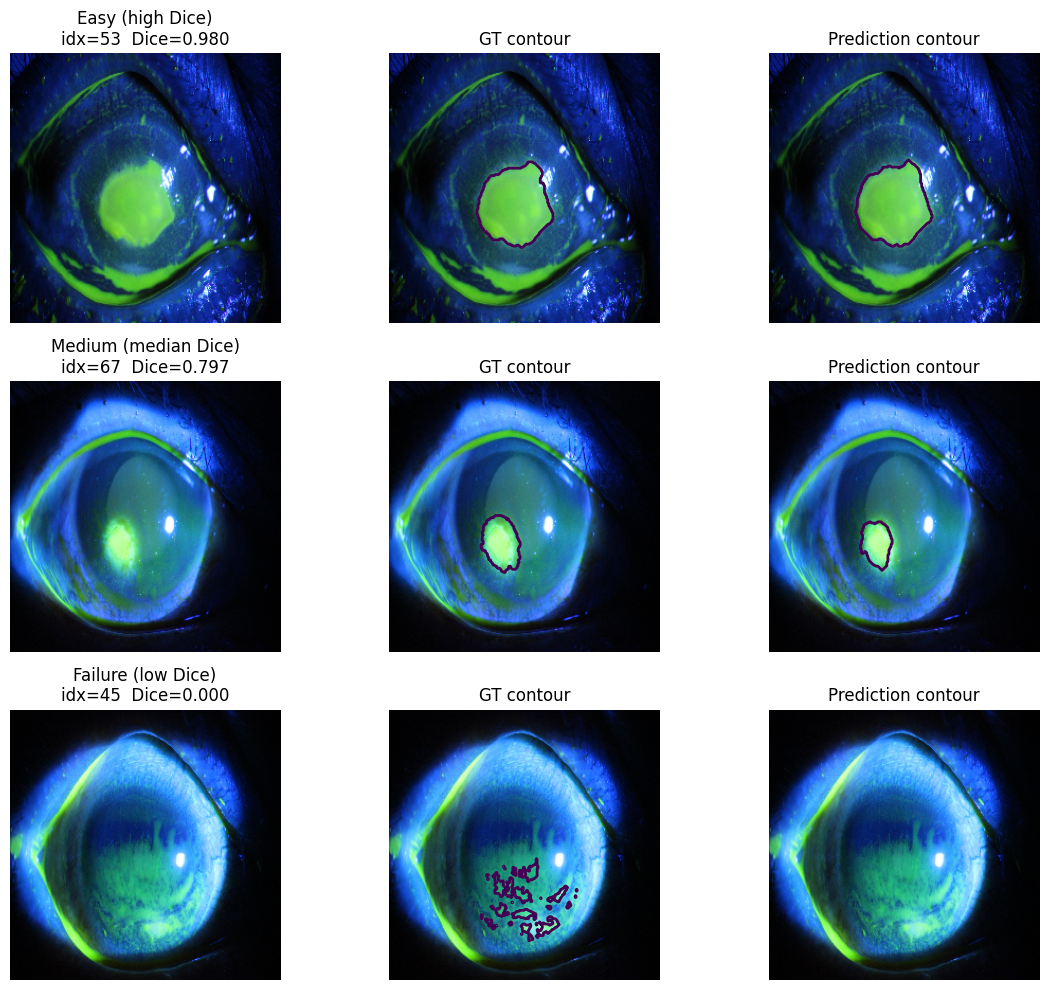

Saved: /content/drive/MyDrive/corneal_ulcer_dataset/qualitative_examples_contours_real_only.png
Picked indices (best, median, worst): [53, 67, 45]
Dice at picked indices: [0.9799128751234375, 0.7971737324201273, 9.000900081907379e-10]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def dice_np(a, b, eps=1e-6):
    a = a.reshape(-1); b = b.reshape(-1)
    return (2*(a*b).sum() + eps) / (a.sum() + b.sum() + eps)

def predict_and_pick(model, X, Y, threshold=0.5):
    probs = model.predict(X, verbose=0)[..., 0]
    pred = (probs > threshold).astype(np.uint8)
    gt = Y[..., 0].astype(np.uint8)

    dices = np.array([dice_np(gt[i], pred[i]) for i in range(len(gt))])

    order = np.argsort(dices)
    worst = int(order[0])
    best = int(order[-1])
    median = int(order[len(order)//2])
    return dices, probs, pred, [best, median, worst]

def save_contour_grid(X, Y, pred_bin, dices, indices, out_path):
    titles = ["Easy (high Dice)", "Medium (median Dice)", "Failure (low Dice)"]
    plt.figure(figsize=(12, 10))

    for r, idx in enumerate(indices):
        img = X[idx]
        gt  = Y[idx, :, :, 0].astype(np.uint8)
        pr  = pred_bin[idx].astype(np.uint8)

        ax = plt.subplot(len(indices), 3, r*3 + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{titles[r]}\nidx={idx}  Dice={dices[idx]:.3f}")

        ax = plt.subplot(len(indices), 3, r*3 + 2)
        ax.imshow(img)
        ax.contour(gt, levels=[0.5], linewidths=2)
        ax.axis("off")
        ax.set_title("GT contour")

        ax = plt.subplot(len(indices), 3, r*3 + 3)
        ax.imshow(img)
        ax.contour(pr, levels=[0.5], linewidths=2)
        ax.axis("off")
        ax.set_title("Prediction contour")

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
    Y_test_eval = Y_test_eval[..., None]

dices, probs, pred_bin, picks = predict_and_pick(model_real_best, X_test_eval, Y_test_eval, threshold=0.5)

out_fig = "/content/drive/MyDrive/corneal_ulcer_dataset/qualitative_examples_contours_real_only.png"
save_contour_grid(X_test_eval, Y_test_eval, pred_bin, dices, picks, out_fig)

print("Picked indices (best, median, worst):", picks)
print("Dice at picked indices:", [float(dices[i]) for i in picks])


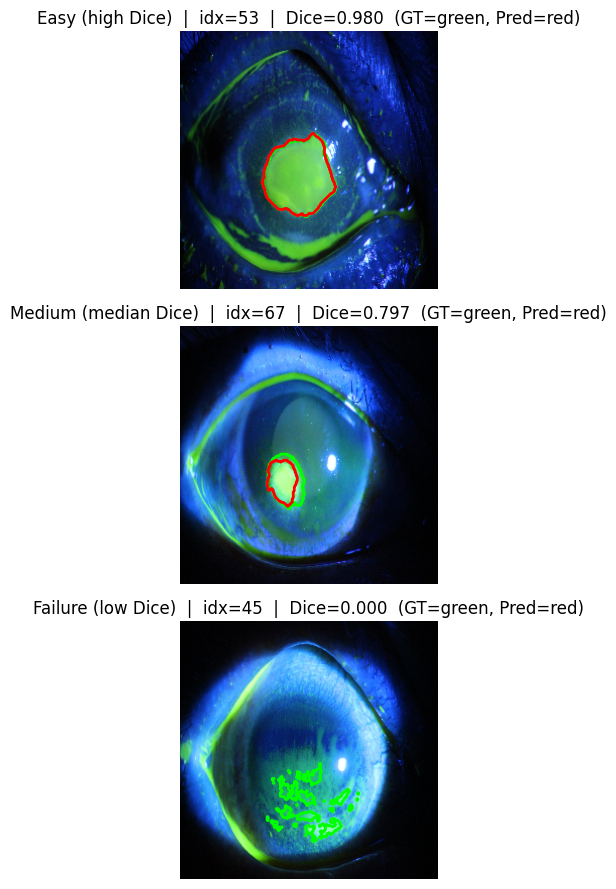

Saved: /content/drive/MyDrive/corneal_ulcer_dataset/qualitative_examples_overlay_real_only.png
Picked indices (best, median, worst): [53, 67, 45]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dice_np(a, b, eps=1e-6):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

def predict_and_pick(model, X, Y, threshold=0.5):
    probs = model.predict(X, verbose=0)[..., 0]
    pred = (probs > threshold).astype(np.uint8)
    gt = Y[..., 0].astype(np.uint8)
    dices = np.array([dice_np(gt[i], pred[i]) for i in range(len(gt))])

    order = np.argsort(dices)
    worst = int(order[0])
    best = int(order[-1])
    median = int(order[len(order)//2])
    return dices, probs, pred, [best, median, worst]

def save_contour_overlay_grid(X, Y, pred_bin, dices, indices, out_path):
    titles = ["Easy (high Dice)", "Medium (median Dice)", "Failure (low Dice)"]
    plt.figure(figsize=(10, 9))

    for r, idx in enumerate(indices):
        img = X[idx]
        gt  = Y[idx, :, :, 0].astype(np.uint8)
        pr  = pred_bin[idx].astype(np.uint8)

        ax = plt.subplot(len(indices), 1, r + 1)
        ax.imshow(img)
        # GT contour (green)
        ax.contour(gt, levels=[0.5], colors=["lime"], linewidths=2)
        # Pred contour (red)
        ax.contour(pr, levels=[0.5], colors=["red"], linewidths=2)
        ax.axis("off")
        ax.set_title(f"{titles[r]}  |  idx={idx}  |  Dice={dices[idx]:.3f}  (GT=green, Pred=red)")

    plt.tight_layout()
    plt.savefig(out_path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

# Run
X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
    Y_test_eval = Y_test_eval[..., None]

dices, probs, pred_bin, picks = predict_and_pick(model_real_best, X_test_eval, Y_test_eval, threshold=0.5)

out_fig = "/content/drive/MyDrive/corneal_ulcer_dataset/qualitative_examples_overlay_real_only.png"
save_contour_overlay_grid(X_test_eval, Y_test_eval, pred_bin, dices, picks, out_fig)

print("Picked indices (best, median, worst):", picks)


In [ ]:
import numpy as np

def per_image_dice(gt, pred, eps=1e-6):
    inter = np.sum(gt * pred, axis=(1,2))
    sums  = np.sum(gt, axis=(1,2)) + np.sum(pred, axis=(1,2))
    return (2*inter + eps) / (sums + eps)

def apply_roi_to_masks(pred_bin, gt_bin, X):
    pred2, gt2 = [], []
    for i in range(len(X)):
        roi = cornea_mask_hough(X[i])
        pred2.append(pred_bin[i] * roi)
        gt2.append(gt_bin[i] * roi)
    return np.array(pred2), np.array(gt2)

probs = model_real_best.predict(X_test_eval, verbose=0)[...,0]
pred = (probs > 0.5).astype(np.uint8)
gt   = Y_test_eval[...,0].astype(np.uint8)

dice_no_roi = per_image_dice(gt, pred)

pred_roi, gt_roi = apply_roi_to_masks(pred, gt, X_test_eval)
dice_roi = per_image_dice(gt_roi, pred_roi)

improved = (dice_roi > dice_no_roi)
pct_improved = 100.0 * improved.mean()
avg_delta = float(np.mean(dice_roi - dice_no_roi))
med_delta = float(np.median(dice_roi - dice_no_roi))

print(f"% images improved with ROI: {pct_improved:.1f}%")
print(f"Average Dice change (ROI - no ROI): {avg_delta:.4f}")
print(f"Median Dice change (ROI - no ROI): {med_delta:.4f}")


% images improved with ROI: 30.6%
Average Dice change (ROI - no ROI): 0.0435
Median Dice change (ROI - no ROI): 0.0000
